In [ ]:
# ============================================
# TEMPLATE PREPROCESSING - REUSABLE
# ============================================

# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (classification_report, 
                             roc_auc_score, 
                             ConfusionMatrixDisplay)

# Decision Tree and Random Forest models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# 1. LOAD DATA
# --------------------------------------------
df = pd.read_csv(r"C:\Users\Giada Jenny Qafalia\Desktop\develhope\TEORIA\data-science-ml-portfolio\data\WA_Fn-UseC_-Telco-Customer-Churn.xls")

# --------------------------------------------
# 2. CLEANING
# --------------------------------------------
# TotalCharges has hidden spaces ' ' → convert to numeric
# errors='coerce' turns invalid values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with NaN (only 11 rows affected)
df.dropna(inplace=True)

# Drop customer ID → not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Encode target variable as binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --------------------------------------------
# 3. DEFINE FEATURES
# --------------------------------------------
# Continuous columns → will be scaled
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Categorical columns → will be one-hot encoded
# Automatically selects all columns except continuous and target
categorical_cols = [col for col in df.columns 
                    if col not in continuous_cols + ['Churn']]

# --------------------------------------------
# 4. ONE-HOT ENCODING
# --------------------------------------------
# drop_first=True avoids the dummy variable trap
# e.g. Gender: Male/Female → only Female column kept
df_encoded = pd.get_dummies(df, 
                             columns=categorical_cols, 
                             drop_first=True)

# --------------------------------------------
# 5. SPLIT X AND y
# --------------------------------------------
# X → all features (everything except target)
# y → target variable (Churn)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# --------------------------------------------
# 6. TRAIN/TEST SPLIT
# --------------------------------------------
# test_size=0.2 → 80% train, 20% test
# stratify=y → preserves class balance in both sets
# random_state=42 → reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
# ══════════════════════════════════════════════════════
# PCA — Principal Component Analysis
# Goal: reduce 30+ features to fewer uncorrelated
#       components while preserving 95% of information
# ══════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [17]:
# ── STEP 2: SCALING ───────────────────────────────────
# StandardScaler is MANDATORY before PCA
# Without scaling, features with large values (e.g.
# TotalCharges: 0-8000) would dominate all components
# fit ONLY on train → then transform both sets separately
# this avoids data leakage from test into train

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # no fit here!

print(f"Original features: {X_train.shape[1]}")
print(f"Train samples:     {X_train.shape[0]}")
print(f"Test samples:      {X_test.shape[0]}")


Original features: 30
Train samples:     5625
Test samples:      1407


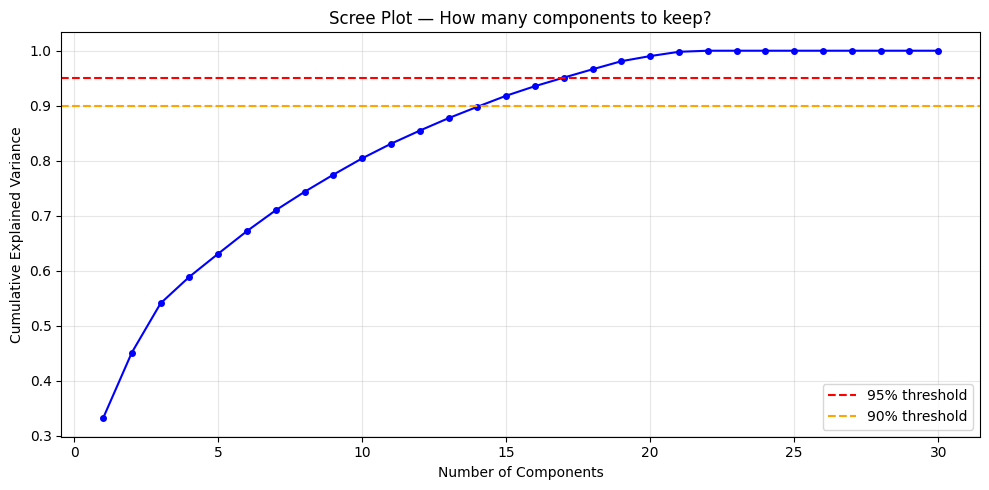


Original features:          30
Components for 90% variance: 15
Components for 95% variance: 17
Dimensionality reduction:    30 → 17 features


In [18]:
# ── STEP 3: SCREE PLOT ────────────────────────────────
# Fit PCA with ALL components first
# This lets us see how much variance each PC explains
# before deciding how many to keep

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

# Cumulative variance explained by each additional PC
# e.g. [0.35, 0.55, 0.70, 0.82, 0.95, ...]
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar,
         'bo-', markersize=4)

# Reference lines for common thresholds
plt.axhline(y=0.95, color='r',
            linestyle='--', label='95% threshold')
plt.axhline(y=0.90, color='orange',
            linestyle='--', label='90% threshold')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot — How many components to keep?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find minimum components needed for 90% and 95% variance
# argmax returns index of first True value in the array
# +1 because index starts at 0 but components start at 1
n_comp_90 = np.argmax(cumvar >= 0.90) + 1
n_comp_95 = np.argmax(cumvar >= 0.95) + 1

print(f"\nOriginal features:          {X_train.shape[1]}")
print(f"Components for 90% variance: {n_comp_90}")
print(f"Components for 95% variance: {n_comp_95}")
print(f"Dimensionality reduction:    "
      f"{X_train.shape[1]} → {n_comp_95} features")



In [19]:
# ── STEP 4: FINAL PCA with chosen n_components ────────
# We use 95% threshold as default
# This keeps most information while reducing noise
# and multicollinearity (e.g. tenure vs TotalCharges)

pca = PCA(n_components=n_comp_95, random_state=42)

# fit_transform on train: learns the components from train
# transform on test: applies same transformation
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"\nShape before PCA: {X_train_scaled.shape}")
print(f"Shape after PCA:  {X_train_pca.shape}")
print(f"Variance retained: "
      f"{pca.explained_variance_ratio_.sum():.2%}")


Shape before PCA: (5625, 30)
Shape after PCA:  (5625, 17)
Variance retained: 95.11%


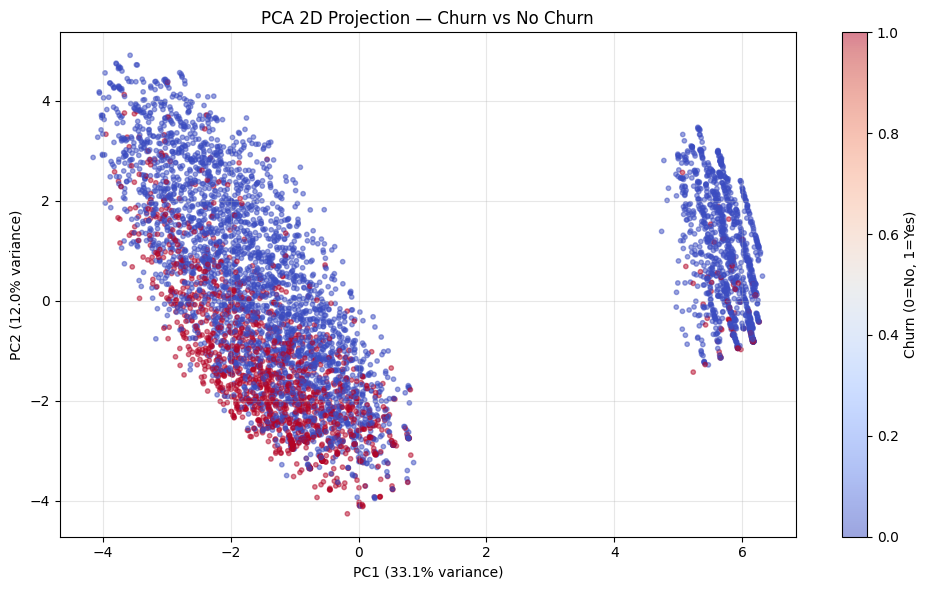

In [20]:
# ── STEP 5: 2D VISUALIZATION ──────────────────────────
# Project data onto first 2 PCs for visualization
# PC1 and PC2 capture the most variance
# Colors show churn (red) vs no churn (blue)
# If colors separate well → PCA captured useful structure

pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label='Churn (0=No, 1=Yes)')
plt.xlabel(
    f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)'
)
plt.ylabel(
    f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)'
)
plt.title('PCA 2D Projection — Churn vs No Churn')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ── STEP 6: COMPARE RF with and without PCA ───────────
# Key question: does PCA hurt or help performance?
# We compare AUC-ROC with and without dimensionality reduction
# Small loss (< 0.02) is acceptable in exchange for:
# → fewer features → faster training
# → less multicollinearity → more stable model
# → less overfitting risk

# Random Forest WITHOUT PCA
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1          # use all CPU cores
)
rf.fit(X_train_scaled, y_train)
auc_no_pca = roc_auc_score(
    y_test,
    rf.predict_proba(X_test_scaled)[:,1]
)

# Random Forest WITH PCA
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_pca.fit(X_train_pca, y_train)
auc_pca = roc_auc_score(
    y_test,
    rf_pca.predict_proba(X_test_pca)[:,1]
)

print("=== PCA Impact on Model Performance ===")
print(f"AUC-ROC without PCA: {auc_no_pca:.3f}")
print(f"AUC-ROC with PCA:    {auc_pca:.3f}")
print(f"Difference:          {abs(auc_no_pca-auc_pca):.3f}")
print(f"Features:            {X_train.shape[1]}"
      f" → {n_comp_95}")
print(f"PCA verdict: "
      f"{'Acceptable loss' if abs(auc_no_pca-auc_pca) < 0.02 else 'Too much loss'}")

=== PCA Impact on Model Performance ===
AUC-ROC without PCA: 0.816
AUC-ROC with PCA:    0.799
Difference:          0.017
Features:            30 → 17
PCA verdict: Acceptable loss


# 📊 PCA Analysis — Telco Customer Churn

---

## Obiettivo
Ridurre le 30 feature originali a un numero minore
di componenti non correlate, mantenendo il 95%
dell'informazione originale ed eliminando la
multicollinearità identificata in precedenza
(es. `tenure` vs `TotalCharges`).

---

## Scree Plot — Selezione n_components

| Soglia | Componenti necessarie | Riduzione |
|---|---|---|
| 90% varianza | 15 PC | 30 → 15 (-50%) |
| **95% varianza** | **17 PC** | **30 → 17 (-43%)** |
| 100% varianza | 30 PC | nessuna riduzione |

> **Scelta:** 17 componenti per mantenere il 95.11%
> della varianza originale — miglior compromesso
> tra riduzione dimensionale e conservazione informazione.

---

## Risultati PCA

| Metrica | Valore |
|---|---|
| Feature originali | 30 |
| Componenti selezionate | 17 |
| Varianza mantenuta | 95.11% |
| Informazione persa | 4.89% |
| Riduzione dimensionale | -43% |

---

## Visualizzazione 2D

La proiezione sui primi 2 componenti principali
(PC1=33.1%, PC2=12.0%, totale=45.1%) rivela:

### Gruppo sinistro (grande):
- Mix di Churn (rosso) e No Churn (blu) sovrapposti
- Le classi **non sono linearmente separabili**
- Conferma che modelli lineari (LogReg, LDA)
  hanno performance limitate su questi dati

### Gruppo destro (piccolo, isolato):
- Principalmente clienti No Churn (blu)
- Ben separato dal gruppo principale
- **Coerente con il Cluster 1 identificato con K-Means**
  → "Clienti Fedeli Low Cost" con spesa bassa

> **Insight:** la struttura trovata da PCA conferma
> quella trovata dal clustering — due approcci
> diversi convergono sullo stesso pattern.

---

## Impatto su Model Performance

| Modello | Feature | AUC-ROC |
|---|---|---|
| RF senza PCA | 30 feature originali | 0.816 |
| **RF con PCA** | **17 componenti** | **0.799** |
| Differenza | -43% feature | -0.017 AUC |

> **Verdetto: Acceptable loss** ✅
> Perdita di 0.017 AUC (< soglia 0.02)
> in cambio di 43% meno feature.

---

## Cosa guadagniamo con PCA

| Vantaggio | Dettaglio |
|---|---|
| Meno feature | 30 → 17 (-43%) |
| Training più veloce | meno dimensioni da processare |
| Zero multicollinearità | le PC sono ortogonali per definizione |
| Meno overfitting | meno feature = meno rumore |
| Multicollinearità risolta | tenure + TotalCharges → assorbite in PC1 |

---

## ⚠️ Limitazioni PCA

- **Nessuna interpretabilità** — le PC non hanno
  un nome o significato diretto come le feature originali
- **Feature Importance non applicabile** — non puoi
  sapere quali feature originali contano di più
- **Relazioni non lineari** — PCA funziona solo con
  strutture lineari nei dati
- **Richiede sempre StandardScaler** prima del fit

---

## 💡 Quando usare PCA su questo dataset

| Situazione | Usa PCA? |
|---|---|
| Performance massima | ❌ RF senza PCA (AUC 0.816) |
| Training veloce su dati grandi | ✅ RF con PCA (AUC 0.799) |
| Interpretabilità richiesta | ❌ Usa Feature Selection |
| Visualizzazione cluster | ✅ PCA 2D ottimo |
| Pre-processing per KNN/SVM | ✅ Riduce curse of dimensionality |

---

